In [1]:
from pyspark.sql import SparkSession

In [2]:
spark = SparkSession.builder \
    .appName("Analisis Pemasukan Dan Penjualan Barang") \
    .getOrCreate()

In [3]:
# Membaca data CSV
pemasukan_barang = spark.read.csv("pemasukan barang.csv", header=True, inferSchema=True)
penjualan_barang = spark.read.csv("penjualan barang.csv", header=True, inferSchema=True)

In [4]:
# Menampilkan skema data
pemasukan_barang.printSchema()
penjualan_barang.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- tanggal: date (nullable = true)
 |-- nama.barang: string (nullable = true)
 |-- kuantum: double (nullable = true)

root
 |-- _c0: integer (nullable = true)
 |-- tanggal: date (nullable = true)
 |-- nama.pembeli: string (nullable = true)
 |-- nama.barang: string (nullable = true)
 |-- kuantum: double (nullable = true)
 |-- nominal: double (nullable = true)



In [5]:
from pyspark.sql.functions import to_date

In [6]:
# Membersihkan data
pemasukan_barang = pemasukan_barang.drop("Unnamed: 0").withColumn("tanggal", to_date(pemasukan_barang["tanggal"], "yyyy-MM-dd"))
penjualan_barang = penjualan_barang.drop("Unnamed: 0").withColumn("tanggal", to_date(penjualan_barang["tanggal"], "yyyy-MM-dd"))

In [7]:
# Menampilkan data sampel
pemasukan_barang.show(5)
penjualan_barang.show(5)

+---+----------+-----------+--------+
|_c0|   tanggal|nama.barang| kuantum|
+---+----------+-----------+--------+
|  1|2020-05-29|       GULA|100000.0|
|  2|2020-07-07|       GULA| 97950.0|
|  3|2020-07-16|       GULA|  2050.0|
|  4|2020-11-12|       GULA| 14000.0|
|  5|2020-12-24|       GULA|  8000.0|
+---+----------+-----------+--------+
only showing top 5 rows

+---+----------+--------------------+-----------+-------+---------+
|_c0|   tanggal|        nama.pembeli|nama.barang|kuantum|  nominal|
+---+----------+--------------------+-----------+-------+---------+
|  1|2020-01-02|    TOKO HERUNIAWATI|      BERAS| 1000.0|9840000.0|
|  2|2020-01-02|    TOKO HERUNIAWATI|     DAGING|  120.0|8400000.0|
|  3|2020-01-02|TOKO APRILIA SUKR...|      BERAS| 6000.0|  6.291E7|
|  4|2020-01-02|TOKO APRILIA SUKR...|      MIGOR|  408.0|4855200.0|
|  5|2020-01-02|TOKO APRILIA SUKR...|     TEPUNG|  140.0|1162000.0|
+---+----------+--------------------+-----------+-------+---------+
only showing top 5 ro

In [9]:
from pyspark.sql.functions import sum

In [10]:
# Ganti nama kolom
pemasukan_barang = pemasukan_barang.withColumnRenamed("nama.barang", "nama_barang")
penjualan_barang = penjualan_barang.withColumnRenamed("nama.barang", "nama_barang")

In [11]:
# Total pemasukan barang
total_pemasukan = pemasukan_barang.groupBy("nama_barang").agg(sum("kuantum").alias("total_pemasukan"))

# Total penjualan barang
total_penjualan = penjualan_barang.groupBy("nama_barang").agg(sum("kuantum").alias("total_penjualan"))

# Menggabungkan pemasukan dan penjualan
supply_demand = total_pemasukan.join(total_penjualan, on="nama_barang", how="outer")

In [12]:
# Menampilkan hasil
supply_demand.show()

+-----------+---------------+---------------+
|nama_barang|total_pemasukan|total_penjualan|
+-----------+---------------+---------------+
|      BERAS|      1975258.0|      1965258.0|
|     DAGING|        16500.0|        15635.0|
|       GULA|       322000.0|       223436.0|
|      MIGOR|        25648.0|        24148.0|
|     TEPUNG|         8500.0|         8020.0|
+-----------+---------------+---------------+



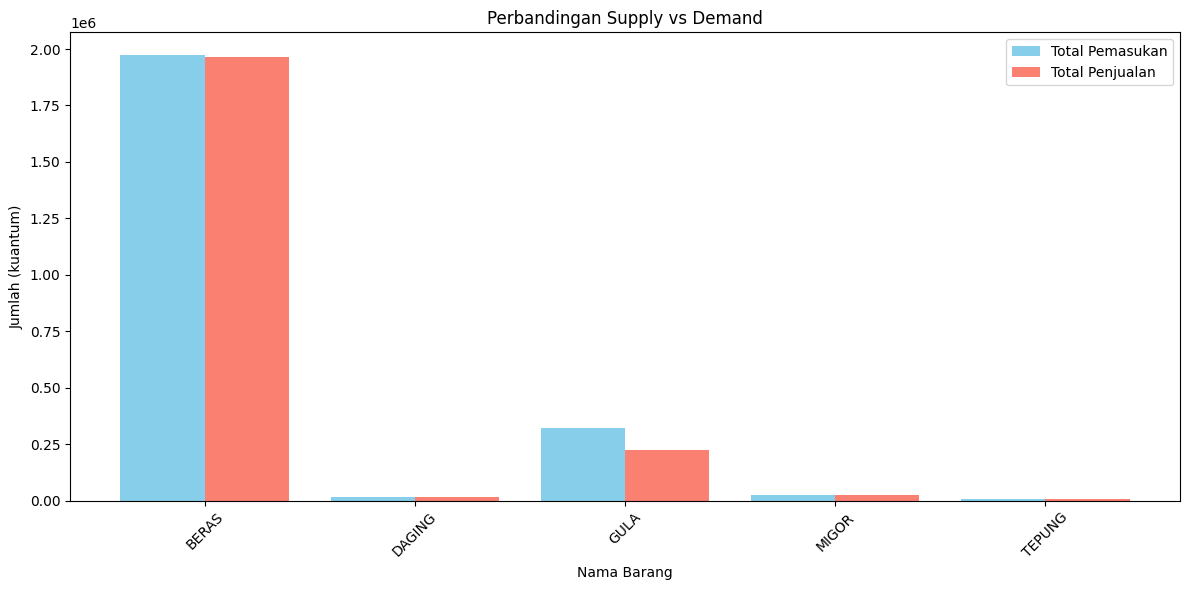

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengonversi hasil Supply vs Demand ke Pandas
supply_demand_pd = supply_demand.toPandas()

# Plot Bar Chart
plt.figure(figsize=(12, 6))

# Plot data
width = 0.4  # Lebar bar
x = range(len(supply_demand_pd["nama_barang"]))

plt.bar(
    x, 
    supply_demand_pd["total_pemasukan"], 
    width=width, 
    label="Total Pemasukan", 
    color="skyblue"
)
plt.bar(
    [p + width for p in x], 
    supply_demand_pd["total_penjualan"], 
    width=width, 
    label="Total Penjualan", 
    color="salmon"
)

# Menambahkan label dan judul
plt.xlabel("Nama Barang")
plt.ylabel("Jumlah (kuantum)")
plt.title("Perbandingan Supply vs Demand")
plt.xticks([p + width / 2 for p in x], supply_demand_pd["nama_barang"], rotation=45)
plt.legend()

# Tampilkan plot
plt.tight_layout()
plt.show()


In [14]:
from pyspark.sql.functions import month, year

In [15]:
# Menambahkan kolom bulan dan tahun
penjualan_tren = penjualan_barang.withColumn("bulan", month("tanggal")).withColumn("tahun", year("tanggal"))

# Menghitung total penjualan per bulan
tren_penjualan = penjualan_tren.groupBy("tahun", "bulan", "nama_barang").agg(sum("kuantum").alias("total_terjual"))

In [16]:
# Menampilkan hasil
tren_penjualan.orderBy("tahun", "bulan").show()

+-----+-----+-----------+-------------+
|tahun|bulan|nama_barang|total_terjual|
+-----+-----+-----------+-------------+
| 2020|    1|      BERAS|     127040.0|
| 2020|    1|     TEPUNG|        500.0|
| 2020|    1|     DAGING|       2220.0|
| 2020|    1|      MIGOR|        696.0|
| 2020|    2|     DAGING|        900.0|
| 2020|    2|      BERAS|     223734.0|
| 2020|    2|      MIGOR|        504.0|
| 2020|    2|     TEPUNG|        280.0|
| 2020|    3|      MIGOR|       2400.0|
| 2020|    3|      BERAS|     152110.0|
| 2020|    3|     DAGING|       1160.0|
| 2020|    3|     TEPUNG|        220.0|
| 2020|    4|      MIGOR|       3300.0|
| 2020|    4|     TEPUNG|       1500.0|
| 2020|    4|      BERAS|      67130.0|
| 2020|    4|     DAGING|       5560.0|
| 2020|    5|      MIGOR|       1804.0|
| 2020|    5|      BERAS|     250000.0|
| 2020|    5|     TEPUNG|        500.0|
| 2020|    6|      MIGOR|       1272.0|
+-----+-----+-----------+-------------+
only showing top 20 rows



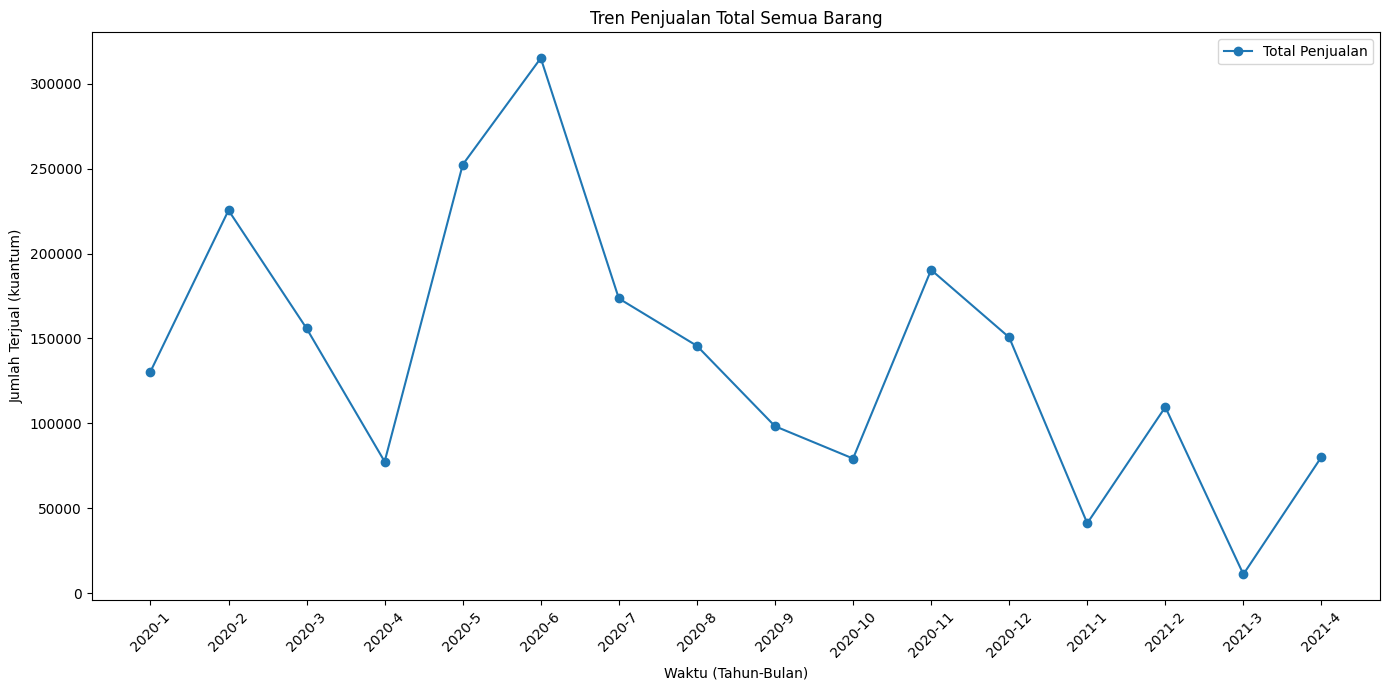

In [27]:
# Menghitung total penjualan per bulan untuk semua barang
tren_penjualan_agregat = tren_penjualan_pd.groupby(["tahun", "bulan"]).agg({"total_terjual": "sum"}).reset_index()

# Plot Line Chart untuk tren penjualan total
plt.figure(figsize=(14, 7))

# Plotkan data total penjualan
plt.plot(
    tren_penjualan_agregat["tahun"].astype(str) + "-" + tren_penjualan_agregat["bulan"].astype(str),
    tren_penjualan_agregat["total_terjual"],
    marker="o",
    label="Total Penjualan"
)

# Menambahkan label dan judul
plt.xlabel("Waktu (Tahun-Bulan)")
plt.ylabel("Jumlah Terjual (kuantum)")
plt.title("Tren Penjualan Total Semua Barang")
plt.xticks(rotation=45)
plt.legend()

# Tampilkan plot
plt.tight_layout()
plt.show()


In [20]:
from pyspark.sql.functions import month, year
from pyspark.sql import functions as F

# Menambahkan kolom bulan dan tahun
penjualan_tren = penjualan_barang.withColumn("bulan", month("tanggal")).withColumn("tahun", year("tanggal"))

# Menghitung total penjualan per bulan
tren_penjualan = penjualan_tren.groupBy("tahun", "bulan", "nama_barang").agg(
    F.sum("kuantum").alias("total_terjual")
)

# Menampilkan data hasil agregasi
tren_penjualan.show(5)


+-----+-----+-----------+-------------+
|tahun|bulan|nama_barang|total_terjual|
+-----+-----+-----------+-------------+
| 2021|    3|     DAGING|       1870.0|
| 2020|    2|     DAGING|        900.0|
| 2021|    2|      MIGOR|       8000.0|
| 2020|    3|      MIGOR|       2400.0|
| 2020|    9|     DAGING|        100.0|
+-----+-----+-----------+-------------+
only showing top 5 rows



In [21]:
from pyspark.ml.feature import VectorAssembler

# Membuat kolom fitur (tahun dan bulan)
feature_cols = ["tahun", "bulan"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Menyiapkan data untuk model
data_ml = assembler.transform(tren_penjualan).select("features", "total_terjual")

# Menampilkan data yang siap untuk model
data_ml.show(5)


+------------+-------------+
|    features|total_terjual|
+------------+-------------+
|[2021.0,3.0]|       1870.0|
|[2020.0,2.0]|        900.0|
|[2021.0,2.0]|       8000.0|
|[2020.0,3.0]|       2400.0|
|[2020.0,9.0]|        100.0|
+------------+-------------+
only showing top 5 rows



In [28]:
# Membagi data menjadi training dan testing
train_data, test_data = data_ml.randomSplit([0.8, 0.2], seed=123)

In [29]:
from pyspark.ml.regression import LinearRegression

# Membuat model Linear Regression
lr = LinearRegression(featuresCol="features", labelCol="total_terjual", predictionCol="predicted_terjual")

# Melatih model
lr_model = lr.fit(train_data)

# Menampilkan koefisien dan intercept
print(f"Koefisien: {lr_model.coefficients}")
print(f"Intercept: {lr_model.intercept}")


Koefisien: [-36838.74562968874,-377.6469167316882]
Intercept: 74467587.00331572


In [31]:
# Membuat prediksi
predictions = lr_model.transform(test_data)

# Menampilkan hasil prediksi
predictions.select("features", "total_terjual", "predicted_terjual").show(5)

# Evaluasi model
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(labelCol="total_terjual", predictionCol="predicted_terjual", metricName="rmse")
rmse = evaluator.evaluate(predictions)
print(f"Root Mean Squared Error (RMSE): {rmse}")


+------------+-------------+-----------------+
|    features|total_terjual|predicted_terjual|
+------------+-------------+-----------------+
|[2020.0,1.0]|       2220.0|52943.18442773819|
|[2020.0,2.0]|        900.0|  52565.537511006|
|[2020.0,4.0]|       1500.0|51810.24367754161|
|[2020.0,4.0]|       3300.0|51810.24367754161|
|[2020.0,5.0]|     250000.0|51432.59676080942|
+------------+-------------+-----------------+
only showing top 5 rows

Root Mean Squared Error (RMSE): 65713.01444938872


In [32]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date, unix_timestamp, when
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator


In [ ]:
# Gabungkan dataset berdasarkan 'tanggal' dan 'nama.barang'
combined_ = pemasukan_barang.join(
    penjualan_barang,
    on=['tanggal', 'nama_barang'],
    how='inner'
).withColumn('stok_harian', col('kuantum') - col('kuantum_y'))
